# 2D Poisson Notebook
Calculates Poisson ratio

In [65]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib inline

def extents(result,frame=0):
    Nbeads = int(np.max(result.dump_id[frame])/2)
    botmask = result.dump_id[frame]<=(Nbeads)
    topmask = result.dump_id[frame]>(Nbeads)
    ytopavg = np.mean(result.dump_y[frame][topmask])
    ybotavg = np.mean(result.dump_y[frame][botmask])
    xmax = np.max(result.dump_x[frame])
    xmin = np.min(result.dump_x[frame])
    x = xmax-xmin
    y = ytopavg-ybotavg
    return (x,y)

# Stretching in x direction

## Run MD

In [64]:
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
t0 = 1.42 * dcore    # structural thickness
wx = 100.0 * dcore    # shell width (arclength along midline)
r0 = "flat"   # set to "flat" for particles with zero curvature
Nbeads = 101    # number of beads per layer (2Nbeads is beads per curvamer)
fraction = 1/3    # middle patch of beads has width = fraction * wx

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0

### Elasticity
kh = 1
# nu = 0.3
d = wx/(Nbeads-1)   # bead spacing
a = t0/d   # aspect ratio
kvkh = 1 
kckh = 1
# kvkh = (12 * t0**2 * (1-nu)) / (-3 * d**2 * (1-nu) + 4 * t0**2) #(12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
# kckh = (3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)

# formula for periodic in x
nuxy = 0.5    # target poisson ratios
nuyx = 0.25
kvkh = (2*nuyx*(1-nuxy*a**2))/(nuxy*(a**2 - nuyx)) 
kckh = (nuyx*(1+a**2))/(a**2 - nuyx)


kv = kh * kvkh
kc = kh * kckh

# single unit cell
# vxy = kc/(kv*(1+a**2) + kc*a**2)
# vyx = (kc*a**2)/(kh*(1+a**2) + kc)

# periodic in x
vxy = 2*kc/(kv*(1+a**2) + 2*kc*a**2)
vyx = (kc*a**2)/(kh*(1+a**2) + kc)

print(f"aspect ratio = {a}")

print(f"kvkh = {kvkh}")
print(f"kckh = {kckh}")

print(f"Predicted vxy = {vxy}")
print(f"Predicted vyx = {vyx}")

aspect ratio = 1.42
kvkh = -0.004642210144927528
kckh = 0.4269134963768116
Predicted vxy = 0.5
Predicted vyx = 0.25


In [51]:
d

0.5

In [61]:
a

1.0

In [50]:
a_list = [3,4]  # aspect ratios (list) 
forcelist = np.linspace(0.001,0.501,100)  # dependent jobs that run in series (list or np array)

rm.print_header(version)

jobcounter = 0
for i in range(len(a_list)):   
    simcounter = 0
    jobcounter += 1

    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")

    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)

    for j in range(len(forcelist)):  

        simcounter += 1

        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry
        dimension = 2
        dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
#         t0 = 1.4 * dcore    # structural thickness
        wx = 100.0 * dcore    # shell width (arclength along midline)
        r0 = "flat"   # set to "flat" for particles with zero curvature
        Nbeads = 101    # number of beads per layer (2Nbeads is beads per curvamer)
        fraction = 1/3    # middle patch of beads has width = fraction * wx

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0

        ### Elasticity
        kh = 1 #kh_list[i]
        nu = 0.3
        d = wx/(Nbeads-1)   # bead spacing
        a = a_list[i] #t0/d  # unit cell aspect ratio
        t0 = a * d  # structural thickness

        kvkh = 1
        kckh = 1

        # formula for periodic in x
        nuxy = 0.3    # target poisson ratios
        nuyx = 0.3
#         kvkh = (2*nuyx*(1-nuxy*a**2))/(nuxy*(a**2 - nuyx)) 
#         kckh = (nuyx*(1+a**2))/(a**2 - nuyx)
        
#         kvkh = (2*(1-nu))/(1-nu+a**2) #(12 * t0**2 * (1-nu)) / (-3 * d**2 * (1-nu) + 4 * t0**2) #(12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
#         kckh = (nu*(1+a**2))/(1-nu+a**2) #(3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)

        ### Interactions
        pair_ints = "none" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = 0
        epsilon = 0
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        config = "stacked" #"dispersed" or "stacked"
        simtype = "md"
        datascript = "stack"    # script to make data file, NO .py EXTENSION, "stack", "load", or "lattice"
        nshells = 1
        datagz = True
        trajgz = True
        dumpbonds = True    # whether to calculate and dump bond data
        screen = False    # output lammps log to screen


        ### Stacked config settings
        k_i = 0 * k_0    # curvature of bottom shell in stack
        xlo = -2*wx
        xhi = 2*wx
        ylo = -4*t0
        yhi = 4*t0
        zlo = -0.5
        zhi = 0.5

        ### Dispersed config settings
        # phi = 0.01    # concentration of molecules (area fraction) - only for MD
        # Nx = 4    # number of particle columns for initial config (applies if simpath_old = "none")
        # Ny = int(nshells/Nx)
        # v0 = wx * (t0 + dcore)
        # lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
        # xlo = -lbox/2
        # xhi = lbox/2
        # ylo = -lbox/2
        # yhi = lbox/2
        # zlo = -0.5
        # zhi = 0.5

        ### Dynamics/Minimization Settings
    #     minstyle = "cg"
    #     etol = 1e-12
    #     maxiter = 100000

        Tstart = 0
        Tstop = Tstart
        Tdamp = 1
        seed = 15298
        timestep = 0.0005
        runsteps = 100000

        dumpfreq = 1000
        thermofreq = 1000

        force  = forcelist[j]

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory if it exists before creating again
        load_simpath = False # location of trajectory file to load in (set to False if not loading in state)
        simpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/stretch-x/kh-{kh:0.3f}/force-{force:0.4f}" # path to simulation directory (relative to PROJECT_ROOT)

        ### Computation
        computer = "local"
    #     computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 0
        tlim_min = 10
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 1 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 1    # number of cpus along x
        py = 1
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?


        #################
        ##### SETUP #####
        #################

        print("--------Creating simulation directory...")

        ### Make simulation directory

        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
    ----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")

        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)

#         ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")

        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file

units lj
dimension {dimension}
boundary s s p
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""

        ### Interactions
        if pair_ints == "none":
            inputcontents += f"""
pair_style none
"""
        elif pair_ints == "repulsive":
            inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

        else:
            if soft_ints == True:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
"""
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
"""


            if pair_ints == "1patch":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
"""
            elif pair_ints == "patchy":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

            elif pair_ints == "attractive":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_modify shift yes
\n
"""

        
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
    #         inputcontents += f"""
    # fix 3 all rigid molecule
    # fix 4 all setforce NULL 0.0 NULL
    # fix 4 all setforce 0.0 0.0 0.0

    # group redge id {Nbeads:g} {2*Nbeads:g}
    # fix 5 redge setforce {force:f} 0.0 0.0
    # fix 5 redge addforce {force:f} 0.0 0.0
    # group ledge id {1:g} {Nbeads+1:g}
    # fix 6 ledge setforce {-force:f} 0.0 0.0
    # fix 6 ledge addforce {force:f} 0.0 0.0"""

            inputcontents += f"""
group redge id {Nbeads:g} {2*Nbeads:g}
fix 5 redge addforce {force:f} 0.0 0.0
group ledge id {1:g} {Nbeads+1:g}
fix 6 ledge addforce -{force:f} 0.0 0.0
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
    #     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)



        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")

        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    't0':t0,
                    'wx':wx,
                    'r0':r0,
                    'Nbeads':Nbeads,
                    'fraction':fraction
                },
                'elasticity':{
                    'nu':nu,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut,

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)

        if config == "stacked":
            stack_params = {'k_i':k_i}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)


        print(f"----Simulation {simcounter} prepared.")

        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                # NEED MD SECTION HERE
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")

            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")


######################################
######################################

    Coarse-Grained Shell Simulator   
    
        Kyle Thomas Sullivan
       kyltsullivan@umass.edu
       
######################################
######################################

Using curvsim v1

######################################
#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.007787227630615234sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 2...
--------Creating simulation directory.

LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 16...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 16 prepared.
Running job 1 sim 16.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008459091186523438sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.0sec
Updating metadata with run info ...

#####################################
----Preparing simulation 17...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 17 prepared.
Running job 1 sim 17.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 31...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 31 prepared.
Running job 1 sim 31.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.007714986801147461sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 32...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 32 prepared.
Running job 1 sim 32.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.0sec
Updating metadata with run info ...

#####################################
----Preparing simulation 46...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 46 prepared.
Running job 1 sim 46.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008356094360351562sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 47...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 47 prepared.
Running job 1 sim 47.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 61...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 61 prepared.
Running job 1 sim 61.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008842945098876953sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 62...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 62 prepared.
Running job 1 sim 62.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

...

LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 36...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 36 prepared.
Running job 2 sim 36.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.009089946746826172sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 37...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 37 prepared.
Running job 2 sim 37.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.0sec
Updating metadata with run info ...

#####################################
----Preparing simulation 51...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 51 prepared.
Running job 2 sim 51.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.007925033569335938sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.0sec
Updating metadata with run info ...

#####################################
----Preparing simulation 52...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 52 prepared.
Running job 2 sim 52.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.0sec
Updating metadata with run info ...

#####################################
----Preparing simulation 66...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 66 prepared.
Running job 2 sim 66.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008549928665161133sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 67...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 67 prepared.
Running job 2 sim 67.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 81...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 81 prepared.
Running job 2 sim 81.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.007760047912597656sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 82...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 82 prepared.
Running job 2 sim 82.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 96...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 96 prepared.
Running job 2 sim 96.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008266925811767578sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 97...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 97 prepared.
Running job 2 sim 97.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

## Read sims and plot

In [51]:
##### PARTICLE #####
### Geometry
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
# t0 = 1.4 * dcore    # structural thickness
wx = 100.0 * dcore    # shell width (arclength along midline)
r0 = "flat"   # set to "flat" for particles with zero curvature
Nbeads = 101    # number of beads per layer (2Nbeads is beads per curvamer)
fraction = 1/3    # middle patch of beads has width = fraction * wx

### Elasticity
nu = 0.3
d = wx/(Nbeads-1)   # bead spacing
# a = t0/d  # aspect ratio

kvkh = 1
kckh = 1

# formula for periodic in x
nuxy = 0.3    # target poisson ratios
nuyx = 0.3
# kvkh = (2*nuyx*(1-nuxy*a**2))/(nuxy*(a**2 - nuyx)) 
# kckh = (nuyx*(1+a**2))/(a**2 - nuyx)

# kvkh = (12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
# kckh = (3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)
# kvkh = (2*(1-nu))/(1-nu+a**2) 
# kckh = (nu*(1+a**2))/(1-nu+a**2)

a_list = [0.1,0.25,0.5,0.75,1,1.5,2,3,4,5,7.5,10]  
forcelist = "all"   # plot all force simulations found in mesh directory
# forcelist = np.linspace(0.001,0.501,100)   # only plot these forces

pratios = []
strains = []
jobcounter = 0
for i in range(len(a_list)):
    a = a_list[i]
    t0 = a * d
    kh = 1 #kh_list[i]
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/stretch-x/kh-{kh:0.3f}" 
    series_simpaths = [] # append simpaths for plotting (i.e. different force values)
    
    if forcelist == "all":

        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            if f[:5] == 'force':
                series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        for j in range(len(forcelist)):  
            force  = forcelist[j]
            simpath = f"{parentsimpath}/force-{force:0.4f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
            
    nulist = []
    xstrainlist = []
    for s in series_simpaths:
        dumpname = "trajectory1.dump.gz"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_dump(dumpname=dumpname,readall=False)
        (x0,y0) = extents(result,frame=0)
        (xf,yf) = extents(result,frame=-1)
        ystrain = (yf-y0)/y0
        xstrain = (xf-x0)/x0
        nu = -ystrain/xstrain
        nulist.append(nu)
        xstrainlist.append(xstrain)
    pratios.append(nulist)
    strains.append(xstrainlist)
    
# pratios = np.array(pratios)
# strains = np.array(strains)
    

Text(0, 0.5, 'Poisson Ratio $-\\epsilon_{yy}/\\epsilon_{xx}$')

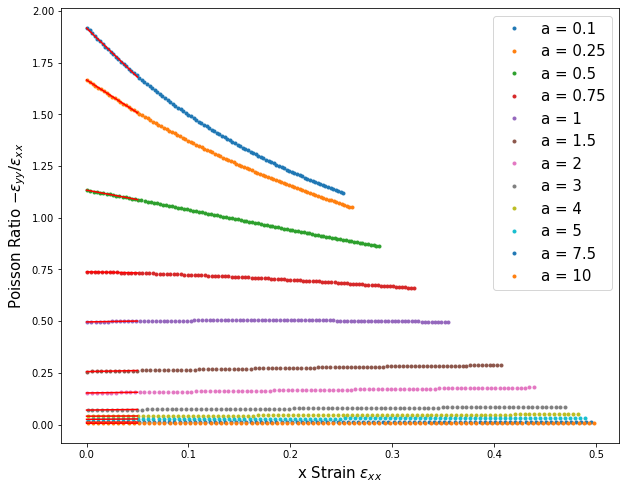

In [52]:
def linfit(x,m,b):
    return m*x+b

maxstrain = 0.05

fig, ax = plt.subplots(1,1,figsize=(10,8))
nuxy_list = []
for i in range(len(strains)):
    mask = (np.array(strains[i])<=maxstrain)
    xdata = np.array(strains[i])[mask]
    ydata = np.array(pratios[i])[mask]
    params,var = curve_fit(linfit,xdata,ydata)
    nuxy_list.append(params[1])
    ax.plot(np.array(strains[i]),np.array(pratios[i]),".",label=f"a = {a_list[i]}")
#     ax.plot(np.linspace(0,maxstrain,100),linfit(np.linspace(0,maxstrain,100),params[0],params[1]),"r-",label = f"a = {a_list[i]} (fit) nu = {params[1]:0.3} +/- {np.sqrt(var[1,1]):0.3}")
    ax.plot(np.linspace(0,maxstrain,100),linfit(np.linspace(0,maxstrain,100),params[0],params[1]),"r-")

# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.15)
ax.legend(fontsize=15)
ax.set_xlabel("x Strain $\epsilon_{xx}$",fontsize=15)
ax.set_ylabel("Poisson Ratio $-\epsilon_{yy}/\epsilon_{xx}$",fontsize=15)


Text(0, 0.5, 'Poisson Ratio $-\\epsilon_{yy}/\\epsilon_{xx}$')

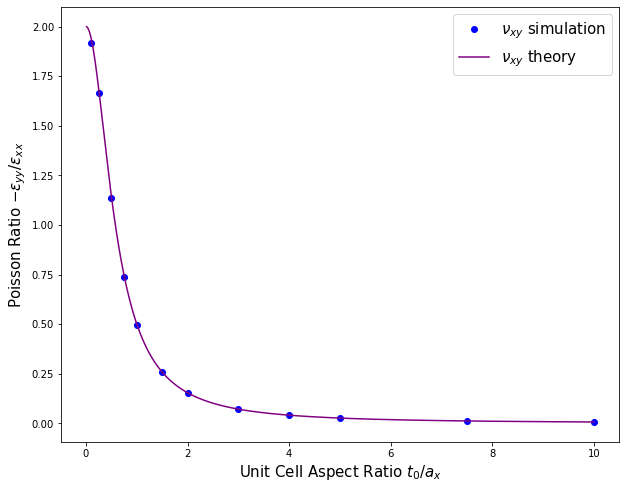

In [53]:
def nuxy_theory(a,kc,kv):
    return (2*kc)/(kv*(1+a**2)+2*kc*a**2)

def nuyx_theory(a,kc,kh):
    return (kc*a**2)/(kh*(1+a**2)+kc)

adata = np.linspace(0.01,10,1000)
fig, ax = plt.subplots(1,1,figsize=(10,8))
ax.plot(np.array(a_list),np.array(nuxy_list),"o",color="blue",label="$\\nu_{xy}$ simulation")
ax.plot(adata,nuxy_theory(adata,kh*kckh,kh*kvkh),"-",color="purple",label="$\\nu_{xy}$ theory")
ax.legend(fontsize=15)
ax.set_xlabel("Unit Cell Aspect Ratio $t_0 / a_x $",fontsize=15)
ax.set_ylabel("Poisson Ratio $-\epsilon_{yy}/\epsilon_{xx}$",fontsize=15)

# Plot atom positions

In [78]:
fi = 99    # force index
frame = -1
s = series_simpaths[fi]
print(s)
dumpname = "trajectory1.dump"
result = ReadSim(f"{PROJECT_ROOT}/{s}")
result.read_dump(dumpname=dumpname,readall=True)

fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(result.dump_x[frame],result.dump_y[frame],"r.")
ax.plot(result.dump_x[0],result.dump_y[0],".")
# botmask = result.dump_id[frame]<=(Nbeads)
# topmask = result.dump_id[frame]>(Nbeads)
# ax.plot(result.dump_x[frame][topmask],result.dump_y[frame][topmask],"ko")
# ax.set_xlim(-wx,wx)
# ax.set_ylim(-wx/30,wx/30)

data/2d/mesh_characteristics/wx-56.000-t0-1.000-Nbeads-150/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-100.000/force-0.2081


FileNotFoundError: [Errno 2] No such file or directory: '/Users/kyle/Documents/Code/cgshells/data/2d/mesh_characteristics/wx-56.000-t0-1.000-Nbeads-150/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-100.000/force-0.2081/trajectory1.dump'

In [86]:
np.max(result.dump_x[frame])-np.min(result.dump_x[frame])

57.1714

In [99]:
ytopavg = np.mean(result.dump_y[frame][topmask])
ybotavg = np.mean(result.dump_y[frame][botmask])
xmax = np.max(result.dump_x[frame])
xmin = np.min(result.dump_x[frame])
x = xmax-xmin
y = ytopavg-ybotavg


In [84]:
evens = result.dump_id[-1]%2==0
mask = result.dump_id[-1]<=(Nbeads)
topmask = result.dump_id[-1]>(Nbeads)

# Stretching in y

## Run MD

In [55]:
a_list = [0.25,0.5,0.75,1.5,2,3,4,5,7.5]  # aspect ratios (list) 
forcelist = np.linspace(0.0005,0.251,100)   # dependent jobs that run in series (list or np array)

rm.print_header(version)

jobcounter = 0
for i in range(len(a_list)):   
    simcounter = 0
    jobcounter += 1

    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")

    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)

    for j in range(len(forcelist)):  

        simcounter += 1

        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry
        dimension = 2
        dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
#         t0 = 1.4 * dcore    # structural thickness
        wx = 100.0 * dcore    # shell width (arclength along midline)
        r0 = "flat"   # set to "flat" for particles with zero curvature
        Nbeads = 101    # number of beads per layer (2Nbeads is beads per curvamer)
        fraction = 1/3    # middle patch of beads has width = fraction * wx

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0

        ### Elasticity
        kh = 1 #kh_list[i]
        nu = 0.3
        d = wx/(Nbeads-1)   # bead spacing
        a = a_list[i] #t0/d  # unit cell aspect ratio
        t0 = a * d  # structural thickness

        kvkh = 1
        kckh = 1

        # formula for periodic in x
        nuxy = 0.3    # target poisson ratios
        nuyx = 0.3
#         kvkh = (2*nuyx*(1-nuxy*a**2))/(nuxy*(a**2 - nuyx)) 
#         kckh = (nuyx*(1+a**2))/(a**2 - nuyx)
        
#         kvkh = (2*(1-nu))/(1-nu+a**2) #(12 * t0**2 * (1-nu)) / (-3 * d**2 * (1-nu) + 4 * t0**2) #(12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
#         kckh = (nu*(1+a**2))/(1-nu+a**2) #(3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)

        ### Interactions
        pair_ints = "none" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = 0
        epsilon = 0
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        config = "stacked" #"dispersed" or "stacked"
        simtype = "md"
        datascript = "stack"    # script to make data file, NO .py EXTENSION, "stack", "load", or "lattice"
        nshells = 1
        datagz = True
        trajgz = True
        dumpbonds = True    # whether to calculate and dump bond data
        screen = False    # output lammps log to screen


        ### Stacked config settings
        k_i = 0 * k_0    # curvature of bottom shell in stack
        xlo = -2*wx
        xhi = 2*wx
        ylo = -4*t0
        yhi = 4*t0
        zlo = -0.5
        zhi = 0.5

        ### Dispersed config settings
        # phi = 0.01    # concentration of molecules (area fraction) - only for MD
        # Nx = 4    # number of particle columns for initial config (applies if simpath_old = "none")
        # Ny = int(nshells/Nx)
        # v0 = wx * (t0 + dcore)
        # lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
        # xlo = -lbox/2
        # xhi = lbox/2
        # ylo = -lbox/2
        # yhi = lbox/2
        # zlo = -0.5
        # zhi = 0.5

        ### Dynamics/Minimization Settings
    #     minstyle = "cg"
    #     etol = 1e-12
    #     maxiter = 100000

        Tstart = 0
        Tstop = Tstart
        Tdamp = 1
        seed = 15298
        timestep = 0.0005
        runsteps = 100000

        dumpfreq = 1000
        thermofreq = 1000

        force  = forcelist[j]

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory if it exists before creating again
        load_simpath = False # location of trajectory file to load in (set to False if not loading in state)
        simpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/stretch-y/kh-{kh:0.3f}/force-{force:0.4f}" # path to simulation directory (relative to PROJECT_ROOT)

        ### Computation
        computer = "local"
    #     computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 0
        tlim_min = 10
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 1 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 1    # number of cpus along x
        py = 1
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?


        #################
        ##### SETUP #####
        #################

        print("--------Creating simulation directory...")

        ### Make simulation directory

        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
    ----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")

        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)

#         ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")

        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file

units lj
dimension {dimension}
boundary s s p
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""

        ### Interactions
        if pair_ints == "none":
            inputcontents += f"""
pair_style none
"""
        elif pair_ints == "repulsive":
            inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

        else:
            if soft_ints == True:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
"""
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
"""


            if pair_ints == "1patch":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
"""
            elif pair_ints == "patchy":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

            elif pair_ints == "attractive":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_modify shift yes
\n
"""

        
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
    #         inputcontents += f"""
    # fix 3 all rigid molecule
    # fix 4 all setforce NULL 0.0 NULL
    # fix 4 all setforce 0.0 0.0 0.0

    # group redge id {Nbeads:g} {2*Nbeads:g}
    # fix 5 redge setforce {force:f} 0.0 0.0
    # fix 5 redge addforce {force:f} 0.0 0.0
    # group ledge id {1:g} {Nbeads+1:g}
    # fix 6 ledge setforce {-force:f} 0.0 0.0
    # fix 6 ledge addforce {force:f} 0.0 0.0"""

            inputcontents += f"""
group tedge id {Nbeads+1:g}:{2*Nbeads:g}
fix 5 tedge addforce 0.0 {force:f} 0.0
group bedge id {1:g}:{Nbeads:g}
fix 6 bedge addforce 0.0 -{force:f} 0.0 
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
    #     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)



        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")

        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    't0':t0,
                    'wx':wx,
                    'r0':r0,
                    'Nbeads':Nbeads,
                    'fraction':fraction
                },
                'elasticity':{
                    'nu':nu,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut,

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)

        if config == "stacked":
            stack_params = {'k_i':k_i}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)


        print(f"----Simulation {simcounter} prepared.")

        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                # NEED MD SECTION HERE
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")

            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")


######################################
######################################

    Coarse-Grained Shell Simulator   
    
        Kyle Thomas Sullivan
       kyltsullivan@umass.edu
       
######################################
######################################

Using curvsim v1

######################################
#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.00812220573425293sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.3sec
Updating metadata with run info ...

#####################################
----Preparing simulation 2...
--------Creating simulation directory..

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 16...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 16 prepared.
Running job 1 sim 16.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008153200149536133sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.3sec
Updating metadata with run info ...

#####################################
----Preparing simulation 17...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 17 prepared.
Running job 1 sim 17.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 31...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 31 prepared.
Running job 1 sim 31.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008383989334106445sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 32...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 32 prepared.
Running job 1 sim 32.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 46...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 46 prepared.
Running job 1 sim 46.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008352041244506836sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 47...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 47 prepared.
Running job 1 sim 47.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.3sec
Updating metadata with run info ...

#####################################
----Preparing simulation 61...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 61 prepared.
Running job 1 sim 61.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.007846832275390625sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.3sec
Updating metadata with run info ...

#####################################
----Preparing simulation 62...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 62 prepared.
Running job 1 sim 62.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

...

LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 40...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 40 prepared.
Running job 9 sim 40.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008469104766845703sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 41...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 41 prepared.
Running job 9 sim 41.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 55...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 55 prepared.
Running job 9 sim 55.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008646726608276367sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.3sec
Updating metadata with run info ...

#####################################
----Preparing simulation 56...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 56 prepared.
Running job 9 sim 56.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 70...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 70 prepared.
Running job 9 sim 70.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.007200002670288086sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 71...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 71 prepared.
Running job 9 sim 71.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 85...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 85 prepared.
Running job 9 sim 85.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008688926696777344sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 86...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 86 prepared.
Running job 9 sim 86.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################
----Preparing simulation 100...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 100 prepared.
Running job 9 sim 100.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.008248090744018555sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 1.2sec
Updating metadata with run info ...

#####################################


## Read Sims and Plot

In [56]:
##### PARTICLE #####
### Geometry
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
# t0 = 1.4 * dcore    # structural thickness
wx = 100.0 * dcore    # shell width (arclength along midline)
r0 = "flat"   # set to "flat" for particles with zero curvature
Nbeads = 101    # number of beads per layer (2Nbeads is beads per curvamer)
fraction = 1/3    # middle patch of beads has width = fraction * wx

### Elasticity
nu = 0.3
d = wx/(Nbeads-1)   # bead spacing
# a = t0/d  # aspect ratio

kvkh = 1
kckh = 1

# formula for periodic in x
nuxy = 0.3    # target poisson ratios
nuyx = 0.3
# kvkh = (2*nuyx*(1-nuxy*a**2))/(nuxy*(a**2 - nuyx)) 
# kckh = (nuyx*(1+a**2))/(a**2 - nuyx)

# kvkh = (12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
# kckh = (3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)
# kvkh = (2*(1-nu))/(1-nu+a**2) 
# kckh = (nu*(1+a**2))/(1-nu+a**2)

a_list = [0.1,0.25,0.5,0.75,1,1.5,2,3,4,5,7.5,10]     
forcelist = "all"   # plot all force simulations found in mesh directory
# forcelist = np.linspace(0.001,0.501,100)   # only plot these forces

pratios = []
strains = []
jobcounter = 0
for i in range(len(a_list)):
    a = a_list[i]
    t0 = a * d
    kh = 1 #kh_list[i]
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/stretch-y/kh-{kh:0.3f}" 
    series_simpaths = [] # append simpaths for plotting (i.e. different force values)
    
    if forcelist == "all":

        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            if f[:5] == 'force':
                series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        for j in range(len(forcelist)):  
            force  = forcelist[j]
            simpath = f"{parentsimpath}/force-{force:0.4f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
            
    nulist = []
    ystrainlist = []
    for s in series_simpaths:
        dumpname = "trajectory1.dump.gz"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_dump(dumpname=dumpname,readall=False)
        (x0,y0) = extents(result,frame=0)
        (xf,yf) = extents(result,frame=-1)
        ystrain = (yf-y0)/y0
        xstrain = (xf-x0)/x0
        nu = -xstrain/ystrain
        nulist.append(nu)
        ystrainlist.append(ystrain)
    pratios.append(nulist)
    strains.append(ystrainlist)
    
# pratios = np.array(pratios)
# strains = np.array(strains)
    

/opt/homebrew/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Text(0, 0.5, 'Poisson Ratio $-\\epsilon_{xx}/\\epsilon_{yy}$')

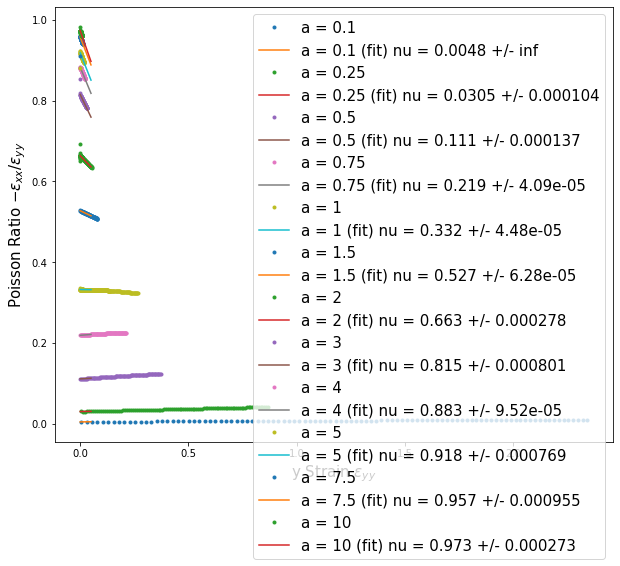

In [57]:
def linfit(x,m,b):
    return m*x+b

maxstrain = 0.05

fig, ax = plt.subplots(1,1,figsize=(10,8))
nuyx_list = []
for i in range(len(strains)):
    mask = (np.array(strains[i])<=maxstrain)
    xdata = np.array(strains[i])[mask]
    ydata = np.array(pratios[i])[mask]
    params,var = curve_fit(linfit,xdata,ydata)
    nuyx_list.append(params[1])
    ax.plot(np.array(strains[i]),np.array(pratios[i]),".",label=f"a = {a_list[i]}")
    ax.plot(np.linspace(0,maxstrain,100),linfit(np.linspace(0,maxstrain,100),params[0],params[1]),"-",label = f"a = {a_list[i]} (fit) nu = {params[1]:0.3} +/- {np.sqrt(var[1,1]):0.3}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.15)
ax.legend(fontsize=15)
ax.set_xlabel("y Strain $\epsilon_{yy}$",fontsize=15)
ax.set_ylabel("Poisson Ratio $-\epsilon_{xx}/\epsilon_{yy}$",fontsize=15) 


Text(0, 0.5, 'Poisson Ratio')

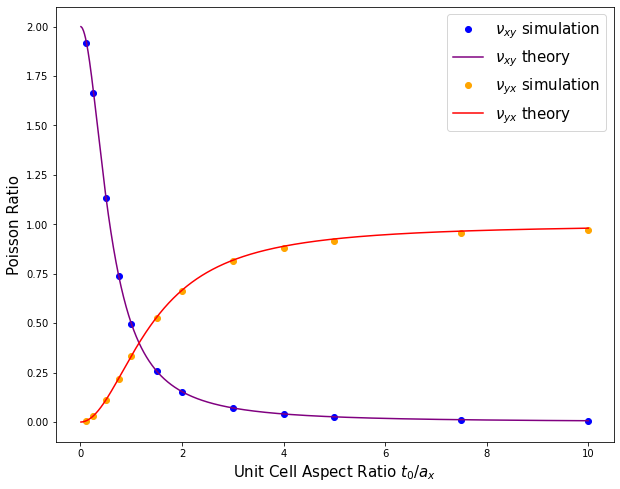

In [60]:
def nuxy_theory(a,kc,kv):
    return (2*kc)/(kv*(1+a**2)+2*kc*a**2)

def nuyx_theory(a,kc,kh):
    return (kc*a**2)/(kh*(1+a**2)+kc)

adata = np.linspace(0.01,10,1000)
fig, ax = plt.subplots(1,1,figsize=(10,8))
ax.plot(np.array(a_list),np.array(nuxy_list),"o",color="blue",label="$\\nu_{xy}$ simulation")
ax.plot(adata,nuxy_theory(adata,kh*kckh,kh*kvkh),"-",color="purple",label="$\\nu_{xy}$ theory")
ax.plot(np.array(a_list),np.array(nuyx_list),"o",color="orange",label="$\\nu_{yx}$ simulation")
ax.plot(adata,nuyx_theory(adata,kh*kckh,kh*kvkh),"r-",label="$\\nu_{yx}$ theory")
ax.legend(fontsize=15)
ax.set_xlabel("Unit Cell Aspect Ratio $t_0 / a_x $",fontsize=15)
# ax.set_ylabel("Poisson Ratio $-\epsilon_{xx}/\epsilon_{yy}$",fontsize=15)
ax.set_ylabel("Poisson Ratio",fontsize=15)